# Configuración básica y carga de datos

In [1]:
import sys
from pathlib import Path
from IPython.display import display, Image
import ipywidgets as widgets
import seaborn as sns
import pandas as pd

# Rutas
PROJECT_ROOT = Path("..").resolve()
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "data" / "Results"
SELECTED_DIR = DATA_PROCESSED / "selected"
EDGE_FILES = [
    DATA_PROCESSED / "edgeData_scen1.csv",
    DATA_PROCESSED / "edgeData_scen2.csv",
]

NET_FILE = DATA_RAW / "simulation" / "algeciras.net.xml"
NET_XML = DATA_RAW / "simulation" / "algeciras.net.xml"


sys.path.append(str(PROJECT_ROOT))

from src.milp_solve import load_milp_inputs, solve_sensor_placement
from src.evaluation import compute_flow_coverage
from scripts import make_sensor_pois
from src.evaluation import compare_milp_vs_ga

# Cargar milp_inputs (si no lo tienes ya cargado)
milp_inputs = load_milp_inputs()



# Cargamos milp_inputs ya preprocesado
milp_inputs = load_milp_inputs()

print("Claves disponibles en milp_inputs:", milp_inputs.keys())
print("Ejemplo flows:")
display(milp_inputs["flows"].head())
print("Ejemplo edges:")
display(milp_inputs["edges"].head())

Claves disponibles en milp_inputs: dict_keys(['flows', 'edges', 'nodes', 'entry_nodes', 'exit_nodes', 'O', 'D', 'M'])
Ejemplo flows:


,scenario,edge_id,tau,begin,end,flow_veh_s,flow_veh_h
0,scen1,-1097680628#0,0,0.0,60.0,0.000000,0.0
1,scen1,-1108932288#2,0,0.0,60.0,0.016667,60.0
2,scen1,-1108932289#0,0,0.0,60.0,0.033333,120.0
3,scen1,-1108932289#1,0,0.0,60.0,0.016667,60.0
4,scen1,-1312203992,0,0.0,60.0,0.000000,0.0


Ejemplo edges:


,edge_id,from_node,to_node
0,-1097680628#0,6380710388,288435676
1,-1108932288#0,12145934094,6295741084
2,-1108932288#1,12145934075,12145934094
3,-1108932288#2,10146578305,12145934075
4,-1108932289#0,5244158193,10146578306


# Re-ejecutar preprocesamiento completo

In [2]:
from src import preprocessing


print("Usando edgeData:")
for p in EDGE_FILES:
    print("  -", p)

print("Usando red:", NET_FILE)

milp_inputs = preprocessing.construir_milp_inputs(

)

print("\nPreprocesamiento completado. milp_inputs.pkl actualizado.")
print("Claves:", milp_inputs.keys())

Usando edgeData:
  - C:\Users\ignag\OneDrive\Documentos\TSLP_algeciras\data\processed\edgeData_scen1.csv
  - C:\Users\ignag\OneDrive\Documentos\TSLP_algeciras\data\processed\edgeData_scen2.csv
Usando red: C:\Users\ignag\OneDrive\Documentos\TSLP_algeciras\data\raw\simulation\algeciras.net.xml
Cargando edgeData desde: C:\Users\ignag\OneDrive\Documentos\TSLP_algeciras\data\processed\edgeData_scen1.csv
Cargando edgeData desde: C:\Users\ignag\OneDrive\Documentos\TSLP_algeciras\data\processed\edgeData_scen2.csv
No se encontró 'nVehContrib'. Usando 'entered' para el flujo.
Leyendo red desde: C:\Users\ignag\OneDrive\Documentos\TSLP_algeciras\data\raw\simulation\algeciras.net.xml
Total de nodos: 1421
Nodos solo-entrada (candidatos O): 15
Nodos solo-salida (candidatos D): 18
O calculado para 190 combinaciones (scenario, node, tau).
D calculado para 122 combinaciones (scenario, node, tau).
Máximo flujo observado (veh/h): 1680.00
Big-M calculado con factor 1.5: 2520.00

Preprocesamiento completado

# Ejecutar el MILP con B sensores

In [3]:
from scripts.run_milp import run_milp_experiment

# Ejecutar MILP con B sensores y guardar selección en data/processed/selected
milp_run = run_milp_experiment(
    B=20,
    selection_dir=DATA_PROCESSED / "selected",
)


display(milp_run["df_cov"])

milp_run

=== Ejecutando MILP de colocación de sensores (formulación tipo paper) ===
Presupuesto de sensores B = 20

Estado del solver: Optimal
Valor óptimo de la función objetivo (suma de residuos + slacks): 999.6
Número de arcos con sensor: 20 (B = 20)

Primeros arcos seleccionados:
  - 1443544286#0
  - 22690112
  - 22740417#2
  - 22740446#6
  - 22740446#7
  - 27235970#12
  - 30917843#5
  - 542415706
  - 542415707#0
  - 542415708#5
  - 542415721#0
  - 669284463
  - 669871301#0
  - 92848429#1
  - 92848448#1.135
  - E10
  - E14
  - E19
  - E37
  - E4

=== Métricas de cobertura de flujo ===
  scenario  total_flow_veh_h  sensed_flow_veh_h  coverage_ratio  num_sensors
0    scen1         7075860.0            39000.0        0.005512           20
1    scen2         1621260.0             9060.0        0.005588           20
2      ALL         8697120.0            48060.0        0.005526           20
Selection file saved to: C:\Users\ignag\OneDrive\Documentos\TSLP_algeciras\data\processed\selected\select

,scenario,total_flow_veh_h,sensed_flow_veh_h,coverage_ratio,num_sensors
0,scen1,7075860.0,39000.0,0.005512,20
1,scen2,1621260.0,9060.0,0.005588,20
2,ALL,8697120.0,48060.0,0.005526,20


{'result': {'status': 'Optimal',
  'objective_value': 999.6,
  'selected_edges': ['1443544286#0',
   '22690112',
   '22740417#2',
   '22740446#6',
   '22740446#7',
   '27235970#12',
   '30917843#5',
   '542415706',
   '542415707#0',
   '542415708#5',
   '542415721#0',
   '669284463',
   '669871301#0',
   '92848429#1',
   '92848448#1.135',
   'E10',
   'E14',
   'E19',
   'E37',
   'E4'],
  'x_values': {'-1097680628#0': 0.0,
   '-1108932288#0': 0.0,
   '-1108932288#1': 0.0,
   '-1108932288#2': 0.0,
   '-1108932289#0': 0.0,
   '-1108932289#1': 0.0,
   '-1312203992': 0.0,
   '-1312204011#0': 0.0,
   '-1312204011#1': 0.0,
   '-1312204011#2': 0.0,
   '-1312204011#3': 0.0,
   '-1312204011#4': 0.0,
   '-1312204017#0': 0.0,
   '-1312204017#1': 0.0,
   '-1312204030#0': 0.0,
   '-1312204030#1': 0.0,
   '-1312242535': 0.0,
   '-1442217813#0': 0.0,
   '-1442217813#1': 0.0,
   '-241782378#0': 0.0,
   '-241782378#1': 0.0,
   '-27235970#10': 0.0,
   '-27235970#11': 0.0,
   '-27235970#12': 0.0,
   '-2

# Ejecutar Algoritmo Genético (GA)

=== Ejecutando Algoritmo Genético para Sensores ===
CSV de entrada: C:\Users\ignag\OneDrive\Documentos\TSLP_algeciras\data\processed\edgeData_scen1.csv
Usando net.xml: C:\Users\ignag\OneDrive\Documentos\TSLP_algeciras\data\raw\simulation\algeciras.net.xml
Leyendo red desde: C:\Users\ignag\OneDrive\Documentos\TSLP_algeciras\data\raw\simulation\algeciras.net.xml
Sistema inicializado: 699 tramos, 965 ecuaciones de conservación.
Número total de tramos (edges): 699
Iniciando Algoritmo Genético...
gen	nevals	min    	avg    
0  	50    	2.96406	3.37727
1  	41    	2.92546	3.20069
2  	43    	2.89393	3.11904
3  	37    	2.88544	3.11471
4  	39    	2.83549	2.98028
5  	41    	2.83549	2.97472
6  	39    	2.79101	2.94339
7  	43    	2.80109	2.94534
8  	43    	2.80109	2.8943 
9  	41    	2.78298	2.86691
10 	41    	2.78298	2.84573
11 	39    	2.78071	2.83119
12 	36    	2.75175	2.82863
13 	42    	2.75893	2.81123
14 	45    	2.75424	2.81279
15 	45    	2.75052	2.81529
16 	48    	2.73526	2.81785
17 	44    	2.7265

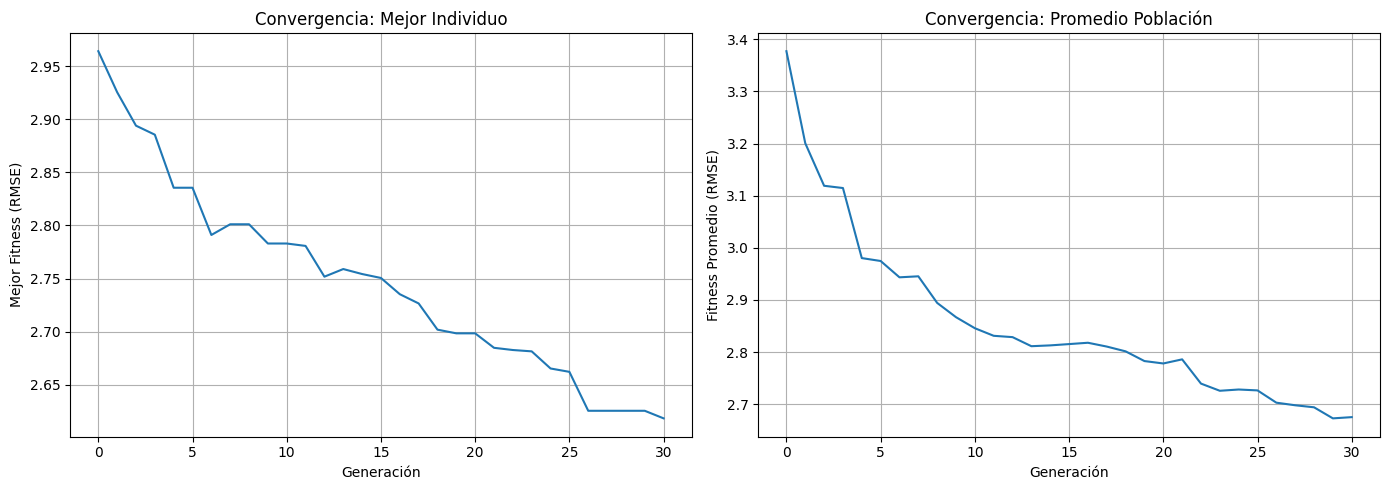

Solución visualizada. Sensores: 20. Fitness (RMSE + penalización): 2.6183


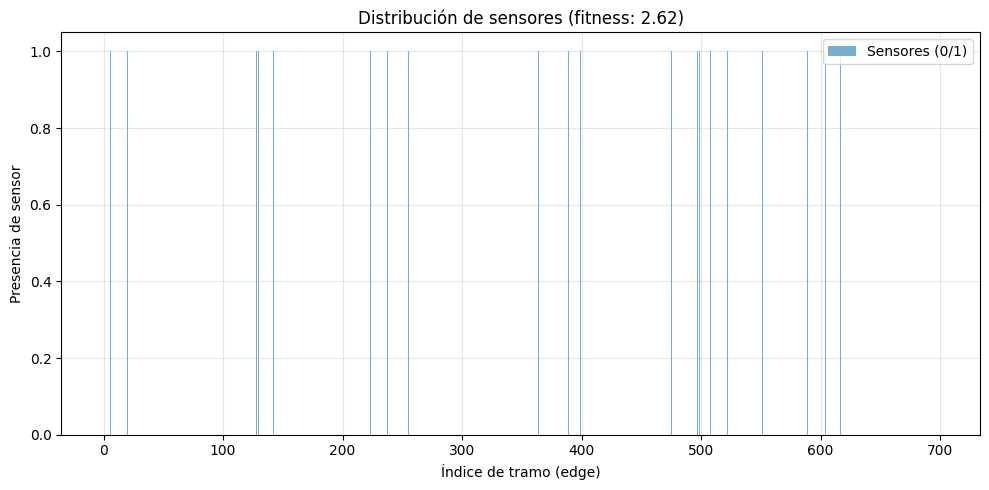

{'best': [0,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  

In [4]:
from scripts.run_ga import run_ga_experiment

ga_result = run_ga_experiment(
    csv_path=DATA_PROCESSED / "edgeData_scen1.csv",
    population_size=50,
    max_generations=30,
    sensor_budget=20,
    net_xml_path=PROJECT_ROOT / "data" / "raw" / "simulation" / "algeciras.net.xml",
)
ga_result

# Generación de additionals en SUMO

In [5]:
import re
from scripts import make_sensor_pois as mpois

NET_XML = DATA_RAW / "simulation" / "algeciras.net.xml"

# Calculamos los shapes una sola vez (más eficiente)
edge_shapes = mpois.cargar_shapes_net(NET_XML)
print(f"Shapes disponibles para {len(edge_shapes)} edges en {NET_XML}")

# Recorremos TODOS los selected_edges_B*.txt (MILP y GA)
for txt_path in sorted(SELECTED_DIR.glob("selected_edges_B*.txt")):
    print(f"\nProcesando {txt_path.name} ...")
    edge_ids = mpois.leer_selected_edges(txt_path)

    stem = txt_path.stem  # p.ej. "selected_edges_B25" o "selected_edges_B99_GA"

    # Buscar el patrón "_B<number>" en el nombre
    m = re.search(r"_B(\d+)", stem)
    if not m:
        print("  (no se pudo extraer B del nombre, se omite)")
        continue

    B = int(m.group(1))

    # Sufijo extra después de "_B<number>" (por ejemplo "_GA" o nada)
    suffix = stem[m.end():]  # desde donde acaba el número hasta el final

    # Construimos el nombre del .add.xml manteniendo el sufijo si existe
    #   selected_edges_B25.txt      → sensors_B25.add.xml
    #   selected_edges_B99_GA.txt   → sensors_B99_GA.add.xml
    if suffix:
        output_add = SELECTED_DIR / f"sensors_B{B}{suffix}.add.xml"
    else:
        output_add = SELECTED_DIR / f"sensors_B{B}.add.xml"

    mpois.escribir_pois(output_add, edge_ids, edge_shapes)

Shapes disponibles para 6912 edges en C:\Users\ignag\OneDrive\Documentos\TSLP_algeciras\data\raw\simulation\algeciras.net.xml

Procesando selected_edges_B10.txt ...
POIs de sensores guardados en: C:\Users\ignag\OneDrive\Documentos\TSLP_algeciras\data\processed\selected\sensors_B10.add.xml

Procesando selected_edges_B13.txt ...
POIs de sensores guardados en: C:\Users\ignag\OneDrive\Documentos\TSLP_algeciras\data\processed\selected\sensors_B13.add.xml

Procesando selected_edges_B15.txt ...
POIs de sensores guardados en: C:\Users\ignag\OneDrive\Documentos\TSLP_algeciras\data\processed\selected\sensors_B15.add.xml

Procesando selected_edges_B20.txt ...
POIs de sensores guardados en: C:\Users\ignag\OneDrive\Documentos\TSLP_algeciras\data\processed\selected\sensors_B20.add.xml

Procesando selected_edges_B20_GA.txt ...
POIs de sensores guardados en: C:\Users\ignag\OneDrive\Documentos\TSLP_algeciras\data\processed\selected\sensors_B20_GA.add.xml

Procesando selected_edges_B20_SA.txt ...
POIs d

# Dashboard sencillo de imágenes de configuración de sensores

In [6]:
def show_milp_image(B: int):
    """
    Muestra la imagen de resultados del MILP almacenada en:
        data/Results/{B}_MILP.png
    """
    img_path = RESULTS_DIR / f"{B}_MILP.png"
    if not img_path.exists():
        print(f"No se encontró la imagen {img_path}")
        return
    display(Image(filename=str(img_path)))

# Widget: deslizador para elegir B (ajusta el rango a tus valores disponibles)
B_slider = widgets.IntSlider(
    value=20,
    min=15,
    max=40,
    step=5,
    description="Sensors B:",
    continuous_update=False,
)

ui = widgets.VBox([B_slider])

out = widgets.Output()

def on_B_change(change):
    if change["name"] == "value":
        B = change["new"]
        out.clear_output()
        with out:
            print(f"Configuración de sensores para B = {B}")
            show_milp_image(B)

B_slider.observe(on_B_change, names="value")

display(ui, out)

# Llamada inicial
on_B_change({"name": "value", "new": B_slider.value})

Output()

In [ ]:
def show_GA_image(B: int):
    """
    Muestra la imagen de resultados del GA almacenada en:
        data/Results/{B}_GA.png
    """
    img_path = RESULTS_DIR / f"{B}_GA.png"
    if not img_path.exists():
        print(f"No se encontró la imagen {img_path}")
        return
    display(Image(filename=str(img_path)))

# Widget: deslizador para elegir B (ajusta el rango a tus valores disponibles)
B_slider = widgets.IntSlider(
    value=20,
    min=20,
    max=98,
    step=10,
    description="Sensors B:",
    continuous_update=False,
)

ui = widgets.VBox([B_slider])

out = widgets.Output()

def on_B_change(change):
    if change["name"] == "value":
        B = change["new"]
        out.clear_output()
        with out:
            print(f"Configuración de sensores para B = {B}")
            show_GA_image(B)

B_slider.observe(on_B_change, names="value")

display(ui, out)

# Llamada inicial
on_B_change({"name": "value", "new": B_slider.value})

Output()

In [8]:
df_comp = compare_milp_vs_ga(
    milp_inputs=milp_inputs,
    selected_dir=SELECTED_DIR,
    results_dir=RESULTS_DIR / "evaluation",
)

display(df_comp)

Budgets B comunes encontrados (MILP & GA): [20, 30, 50]

=== Comparando B = 20 ===
Figura de comparación guardada en: C:\Users\ignag\OneDrive\Documentos\TSLP_algeciras\data\Results\evaluation\comparison_MILP_vs_GA_B20.png

=== Comparando B = 30 ===
Figura de comparación guardada en: C:\Users\ignag\OneDrive\Documentos\TSLP_algeciras\data\Results\evaluation\comparison_MILP_vs_GA_B30.png

=== Comparando B = 50 ===
Figura de comparación guardada en: C:\Users\ignag\OneDrive\Documentos\TSLP_algeciras\data\Results\evaluation\comparison_MILP_vs_GA_B50.png


,B,algo,scenario,total_flow_veh_h,sensed_flow_veh_h,coverage_ratio
0,20,MILP,ALL,8697120.0,708900.0,0.081510
1,20,GA,ALL,8697120.0,290700.0,0.033425
2,30,MILP,ALL,8697120.0,41880.0,0.004815
3,30,GA,ALL,8697120.0,1027140.0,0.118101
4,50,MILP,ALL,8697120.0,1285740.0,0.147835
5,50,GA,ALL,8697120.0,1285740.0,0.147835


# Simulated Annealing (SA)

In [9]:
from src.sa_algorithm import SimulatedAnnealing, build_domain_from_preprocessing
from src.ga_algorithm import save_ga_solution  # la función ya sabe leer domain.edge_ids

# 1) Construir dominio a partir del preprocessing
#    (usa los edgeData_scen*.csv y genera un flujo medio por edge)
domain = build_domain_from_preprocessing()

budget = 20

print(f"Running SA with B={budget}...")
sa = SimulatedAnnealing(
    domain=domain,
    budget=budget,
    max_iter=250,
    initial_temp=1000.0,
)

sa_result = sa.run(seed=42)

print("Best SA Fitness (uncovered flow):", sa_result["best_fitness"])
print("Active sensors in best solution:", int(sa_result["best_solution"].sum()))

# 2) Guardar solución en formato compatible con SUMO/NETEDIT
output_sa_path = DATA_PROCESSED / "selected" / f"selected_edges_B{budget}_SA.txt"
save_ga_solution(sa_result["best_solution"], domain, output_sa_path)
print(f"SA Solution saved to {output_sa_path}")


Cargando edgeData desde: C:\Users\ignag\OneDrive\Documentos\TSLP_algeciras\data\processed\edgeData_scen1.csv
Cargando edgeData desde: C:\Users\ignag\OneDrive\Documentos\TSLP_algeciras\data\processed\edgeData_scen2.csv
No se encontró 'nVehContrib'. Usando 'entered' para el flujo.
[build_domain_from_preprocessing] Dominio construido con 699 edges.
Running SA with B=20...
Best SA Fitness (uncovered flow): 137959.0986143782
Active sensors in best solution: 20
[GA] Solución guardada en: C:\Users\ignag\OneDrive\Documentos\TSLP_algeciras\data\processed\selected\selected_edges_B20_SA.txt
SA Solution saved to C:\Users\ignag\OneDrive\Documentos\TSLP_algeciras\data\processed\selected\selected_edges_B20_SA.txt


# Multi-Seed Experiments & Variance Analysis

Leyendo red desde: C:\Users\ignag\OneDrive\Documentos\TSLP_algeciras\data\raw\simulation\algeciras.net.xml
Sistema inicializado: 699 tramos, 965 ecuaciones de conservación.
Running Multi-seed GA...


Running GA B=20: 100%|██████████| 5/5 [04:08<00:00, 49.62s/it]


Running Multi-seed SA...


Running SA B=20: 100%|██████████| 5/5 [01:28<00:00, 17.75s/it]


,count,mean,std,min,25%,50%,75%,max
algorithm,,,,,,,,
GA,5.0,2.843447,0.022058,2.820356,2.824272,2.843786,2.855291,2.873530
SA,5.0,2.941622,0.054200,2.875505,2.917658,2.923936,2.977000,3.014013


Plot saved to C:\Users\ignag\OneDrive\Documentos\TSLP_algeciras\data\Results\variance_analysis.png


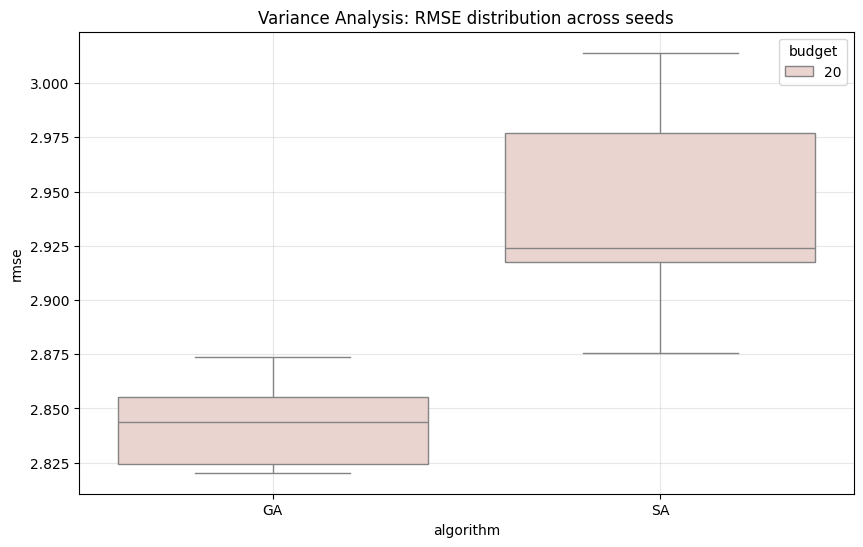

In [10]:
from src.experiments import run_multi_seed_experiment, plot_variance_analysis
import pandas as pd

from src.ga_algorithm import TrafficNetwork
from src.sa_algorithm import SimulatedAnnealing

network = TrafficNetwork(DATA_PROCESSED / "edgeData_scen1.csv")

# Define seeds
seeds = [42, 10, 2023, 777, 99]
budget = 20

# Run GA
print("Running Multi-seed GA...")
df_ga = run_multi_seed_experiment(
    network,
    "GA",
    budget,
    seeds,
    population_size=50,
    max_generations=10,
)

# Run SA (mismos seeds, misma B, pero con hiperparámetros de SA)
print("Running Multi-seed SA...")
df_sa = run_multi_seed_experiment(
    network,
    "SA",
    budget,
    seeds,
    max_iter= 500,
    initial_temp=5000.0,   
    cooling_rate=0.95,     
    min_temp=1.0,          
)
# Combine results
df_all = pd.concat([df_ga, df_sa], ignore_index=True)

# Display results (misma métrica RMSE para GA y SA)
display(df_all.groupby("algorithm")["rmse"].describe())

# Plot Variance
output_plot = RESULTS_DIR / "variance_analysis.png"
plot_variance_analysis(df_all, output_path=output_plot)